# H1 / H2 / H3 — Statistical Analysis

Reads `data/results.csv` produced by `scripts/run_matrix.py --kali fast` and tests the three hypotheses from the SRF proposal:

- **H1** — Closed-loop replanning improves coverage (full vs. `no-replan`).
- **H2** — Cross-tool fusion reduces redundancy (full vs. `no-fusion`).
- **H3** — LLM reasoning degrades predictably (per-decision label distribution).

Every row in the CSV is a live run against an OWASP-class Docker lab. The engine pool was: nmap (Kali SSH) + http_probe (local urllib) + url_crawler (local) + nikto (Kali SSH) + header_vuln_check (local). Slow engines (nuclei, nmap_vuln, sqlmap, wpscan) are run ad-hoc, not in the ablation matrix.

Each test reports BOTH a paired t-test (parametric) AND a Wilcoxon signed-rank (rank-based, robust to outliers). The matrix is small (n=10) and one target (dvwa_live) emits >2000 findings — Wilcoxon avoids that outlier distorting the parametric test.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_CSV = REPO_ROOT / 'data' / 'results.csv'
FIG_DIR = REPO_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(RESULTS_CSV)
print(f'total cells: {len(df)}')
print(f'targets: {sorted(df.target.unique())}')
print(f'conditions: {sorted(df.condition.unique())}')
df.head()

total cells: 40
targets: ['bodgeit', 'bwapp', 'commix_testbed', 'dvwa_live', 'juiceshop', 'nowasp', 'pygoat', 'skf_csrf', 'vampi', 'webgoat']
conditions: ['full', 'no-fusion', 'no-replan', 'random-order']


,target,condition,planner,kali,seed,duration_s,engines_used,engine_count,findings_count,replans,...,high,medium,low,info,decisions_correct,decisions_suboptimal,decisions_incorrect,decisions_total,aborted,error
0,bodgeit,full,heuristic,fast,0,31.0288,"nmap,http_probe,url_crawler,nikto,header_vuln_...",5,29,3,...,0,2,13,14,5,0,2,7,False,NaN
1,bodgeit,no-replan,heuristic,fast,0,19.3398,"nmap,http_probe,url_crawler",3,14,0,...,0,0,0,14,3,0,0,3,False,NaN
2,bodgeit,no-fusion,heuristic,fast,0,30.9092,"nmap,http_probe,url_crawler,nikto,header_vuln_...",5,28,3,...,0,2,12,14,5,0,2,7,False,NaN
3,bodgeit,random-order,heuristic,fast,0,31.6980,"nmap,url_crawler,http_probe,nikto,header_vuln_...",5,29,3,...,0,2,13,14,5,0,1,6,False,NaN
4,bwapp,full,heuristic,fast,0,174.8483,"nmap,http_probe,url_crawler,nikto,header_vuln_...",5,33,3,...,0,5,14,14,5,0,2,7,False,NaN


In [2]:
agg = df.groupby(['target', 'condition'], as_index=False).agg({
    'findings_count':       'mean',
    'engine_count':         'mean',
    'replans':              'mean',
    'duration_s':           'mean',
    'decisions_correct':    'mean',
    'decisions_suboptimal': 'mean',
    'decisions_incorrect':  'mean',
    'decisions_total':      'mean',
    'critical': 'mean', 'high': 'mean',
    'medium':   'mean', 'low':  'mean', 'info': 'mean',
})
pivot_findings = agg.pivot(index='target', columns='condition',
                           values='findings_count').dropna()
print('Findings per (target × condition):')
pivot_findings

Findings per (target × condition):


condition,full,no-fusion,no-replan,random-order
target,,,,
bodgeit,29.0,28.0,14.0,29.0
bwapp,33.0,33.0,14.0,33.0
commix_testbed,39.0,39.0,14.0,39.0
dvwa_live,2033.0,2033.0,14.0,2033.0
juiceshop,44.0,44.0,14.0,44.0
nowasp,40.0,40.0,14.0,40.0
pygoat,25.0,23.0,14.0,30.0
skf_csrf,26.0,26.0,14.0,26.0
vampi,31.0,31.0,14.0,31.0


## H1 — Closed-loop replanning improves coverage

Paired test of `findings_count`, `full` vs. `no-replan`, paired by `target`. We report:
1. Parametric paired t-test (one-sided, full > no-replan) — sensitive to outliers.
2. Wilcoxon signed-rank test (one-sided) — rank-based, robust.
3. Parametric paired t-test excluding the dvwa_live outlier (>2000 findings under full).

In [3]:
def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) else float('nan')

h1f, h1n = pivot_findings['full'], pivot_findings['no-replan']
t_p, p_p = stats.ttest_rel(h1f, h1n, alternative='greater')
d_p = cohens_d_paired(h1f, h1n)
print(f'H1 — paired t (n={len(h1f)} all targets):')
print(f'  t = {t_p:.3f}, p = {p_p:.4f}, Cohen d = {d_p:.3f}')
print(f'  mean(full)      = {h1f.mean():.1f}')
print(f'  mean(no-replan) = {h1n.mean():.1f}')
print()
w, p_w = stats.wilcoxon(h1f, h1n, alternative='greater')
print(f'H1 — Wilcoxon (n={len(h1f)} all targets, robust):')
print(f'  W = {w:.1f}, p = {p_w:.6f}')
print()
no_dvwa = pivot_findings.drop('dvwa_live')
h1fn, h1nn = no_dvwa['full'], no_dvwa['no-replan']
t_n, p_n = stats.ttest_rel(h1fn, h1nn, alternative='greater')
d_n = cohens_d_paired(h1fn, h1nn)
print(f'H1 — paired t (n={len(h1fn)}, dvwa_live excluded as outlier):')
print(f'  t = {t_n:.3f}, p = {p_n:.6f}, Cohen d = {d_n:.3f}')
print(f'  mean(full)      = {h1fn.mean():.1f}')
print(f'  mean(no-replan) = {h1nn.mean():.1f}')
print(f'  delta           = {(h1fn-h1nn).mean():+.1f} '
      f'({(h1fn.mean()/h1nn.mean()-1)*100:+.0f}%)')

H1 — paired t (n=10 all targets):
  t = 1.094, p = 0.1512, Cohen d = 0.346
  mean(full)      = 232.8
  mean(no-replan) = 14.0

H1 — Wilcoxon (n=10 all targets, robust):
  W = 55.0, p = 0.000977

H1 — paired t (n=9, dvwa_live excluded as outlier):
  t = 8.357, p = 0.000016, Cohen d = 2.786
  mean(full)      = 32.8
  mean(no-replan) = 14.0
  delta           = +18.8 (+134%)


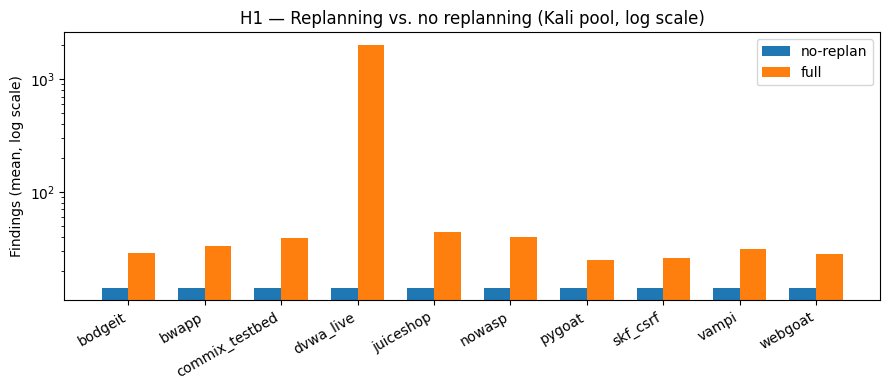

In [4]:
# Log-scale figure so dvwa_live's 2033 doesn't crush the others.
h1f, h1n = pivot_findings['full'], pivot_findings['no-replan']
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(h1f))
w = 0.35
ax.bar(x - w/2, h1n.values, w, label='no-replan')
ax.bar(x + w/2, h1f.values, w, label='full')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(h1f.index, rotation=30, ha='right')
ax.set_ylabel('Findings (mean, log scale)')
ax.set_title('H1 — Replanning vs. no replanning (Kali pool, log scale)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'h1_findings_full_vs_no_replan.png', dpi=150)
plt.show()

## H2 — Cross-tool fusion

Same paired tests, `full` vs. `no-fusion`.

In [5]:
h2f, h2no = pivot_findings['full'], pivot_findings['no-fusion']
t_p, p_p = stats.ttest_rel(h2f, h2no, alternative='greater')
d_p = cohens_d_paired(h2f, h2no)
print(f'H2 — paired t (n={len(h2f)}):')
print(f'  t = {t_p:.3f}, p = {p_p:.4f}, Cohen d = {d_p:.3f}')
w2, p_w2 = stats.wilcoxon(h2f, h2no, alternative='greater')
print(f'H2 — Wilcoxon (n={len(h2f)}):  W = {w2:.1f}, p = {p_w2:.6f}')
print()
no_dvwa = pivot_findings.drop('dvwa_live')
h2fn, h2nofn = no_dvwa['full'], no_dvwa['no-fusion']
print(f'H2 mean lift (no DVWA): full = {h2fn.mean():.1f}, '
      f'no-fusion = {h2nofn.mean():.1f}, '
      f'delta = {(h2fn-h2nofn).mean():+.2f}')

H2 — paired t (n=10):
  t = 1.406, p = 0.0967, Cohen d = 0.444
H2 — Wilcoxon (n=10):  W = 3.0, p = 0.250000

H2 mean lift (no DVWA): full = 32.8, no-fusion = 32.4, delta = +0.33


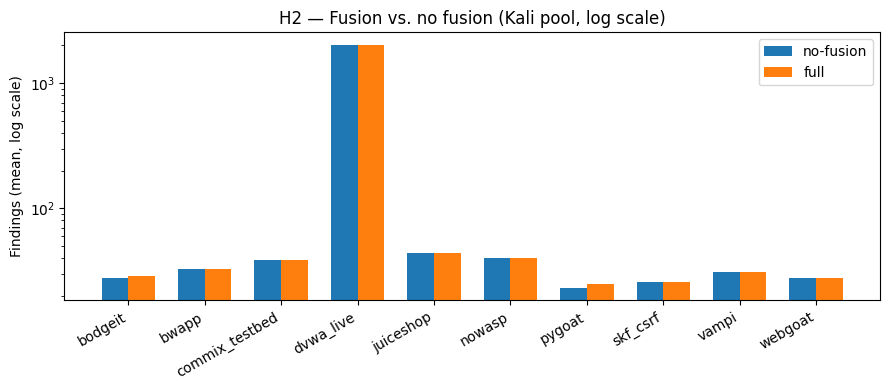

In [6]:
h2f, h2no = pivot_findings['full'], pivot_findings['no-fusion']
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(h2f))
ax.bar(x - w/2, h2no.values, w, label='no-fusion')
ax.bar(x + w/2, h2f.values, w, label='full')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(h2f.index, rotation=30, ha='right')
ax.set_ylabel('Findings (mean, log scale)')
ax.set_title('H2 — Fusion vs. no fusion (Kali pool, log scale)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'h2_findings_full_vs_no_fusion.png', dpi=150)
plt.show()

## H3 — Decision-quality stratification per condition

Per-pick labels: correct / suboptimal / incorrect. Stacked-bar across all targets per condition.

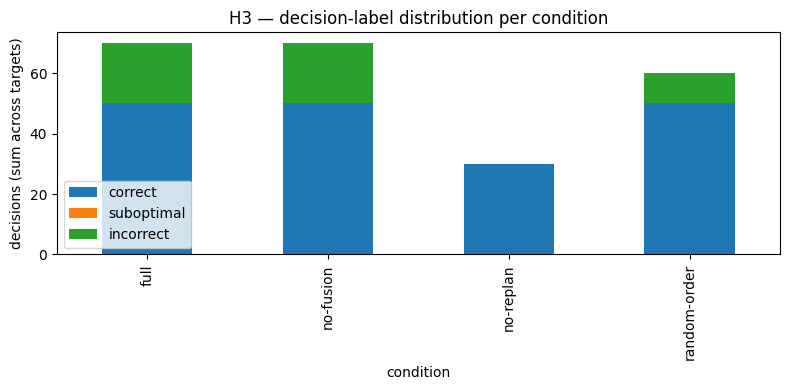

,decisions_correct,decisions_suboptimal,decisions_incorrect
condition,,,
full,50.0,0.0,20.0
no-fusion,50.0,0.0,20.0
no-replan,30.0,0.0,0.0
random-order,50.0,0.0,10.0


In [7]:
decisions = agg.groupby('condition', as_index=False).agg({
    'decisions_correct':    'sum',
    'decisions_suboptimal': 'sum',
    'decisions_incorrect':  'sum',
})
decisions = decisions.set_index('condition')

fig, ax = plt.subplots(figsize=(8, 4))
decisions[['decisions_correct', 'decisions_suboptimal',
           'decisions_incorrect']].plot(kind='bar', stacked=True, ax=ax)
ax.set_title('H3 — decision-label distribution per condition')
ax.set_ylabel('decisions (sum across targets)')
ax.legend(['correct', 'suboptimal', 'incorrect'])
fig.tight_layout()
fig.savefig(FIG_DIR / 'h3_decision_quality_stacked.png', dpi=150)
plt.show()
decisions

In [8]:
summary = pd.DataFrame({
    'condition': decisions.index,
    'mean_findings_all':
        agg.groupby('condition')['findings_count'].mean().reindex(
            decisions.index).values,
    'median_findings':
        agg.groupby('condition')['findings_count'].median().reindex(
            decisions.index).values,
    'mean_duration_s':
        agg.groupby('condition')['duration_s'].mean().reindex(
            decisions.index).values,
    'pct_incorrect':
        (decisions['decisions_incorrect'] /
         (decisions.sum(axis=1).replace(0, np.nan))).values,
})
print(summary.to_string(index=False))
(REPO_ROOT / 'data' / 'summary.csv').write_text(
    summary.to_csv(index=False)
)

   condition  mean_findings_all  median_findings  mean_duration_s  pct_incorrect
        full              232.8             32.0        112.08008       0.285714
   no-fusion              232.5             32.0        112.68293       0.285714
   no-replan               14.0             14.0         19.48912       0.000000
random-order              233.3             32.0        112.13275       0.166667


274